# **2.** Comparación estadística de Energía de señales EEG

In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
import glob
import os

#### **1.** Implemente una función que reciba una señal de múltiples canales y épocas y calcule la Energía de promedio de cada canal

In [ ]:
def calcular_energia_promedio(senal):
    """
    Recibe una matriz de EEG con forma (canales, muestras, épocas).
    Retorna un arreglo 1D con la energía promedio de cada canal.
    """
    # 1. Energía por época: Sumamos los valores al cuadrado a lo largo de las muestras (axis=1)
    energia_epocas = np.sum(senal**2, axis=1)
    
    # 2. Energía promedio: Promediamos esas energías a lo largo de las épocas (axis=1 en la nueva matriz)
    energia_promedio = np.mean(energia_epocas, axis=1)
    
    return energia_promedio

#### **2.** Calcule la energía de cada canal promediada por épocas para cada sujeto, esto para ambos grupos poblacionales. Guarde esta información en un DataFrame de columnas ‘canal’ y filas ‘#sujeto’ con los valores de energía calculados, un DataFrame para cada grupo poblacional.

In [ ]:
def lectura_carpeta_eeg(ruta_carpeta, prefijo_archivo):
    """
    Lee archivos .mat de una carpeta, calcula la energía promedio de cada canal
    y retorna un DataFrame.
    """
    # Busca todos los archivos en la carpeta que coincidan con el prefijo (ej. 'p*.mat')
    patron_busqueda = os.path.join(ruta_carpeta, f'{prefijo_archivo}*.mat')
    archivos = glob.glob(patron_busqueda)
    
    datos_sujetos = []
    nombres_sujetos = []
    
    for archivo in archivos:
        # Cargar el archivo .mat
        mat_data = sio.loadmat(archivo)
        
        # Extraer la variable con los datos 
        llaves_validas = [k for k in mat_data.keys() if not k.startswith('__')]
        llave_datos = llaves_validas[0] 
        senal_eeg = mat_data[llave_datos]
        
        # Calcular la energía pasando los datos a nuestra función
        energia_canales = calcular_energia_promedio(senal_eeg)
        datos_sujetos.append(energia_canales)
        
        # Guardar el nombre del archivo para usarlo como nombre de sujeto
        nombre_sujeto = os.path.basename(archivo).replace('.mat', '')
        nombres_sujetos.append(nombre_sujeto)
        
    # Crear el DataFrame
    num_canales = len(datos_sujetos[0]) if datos_sujetos else 0
    nombres_canales = [f'Canal_{i+1}' for i in range(num_canales)]
    
    df = pd.DataFrame(datos_sujetos, index=nombres_sujetos, columns=nombres_canales).round(2)
    df.index.name = '#sujeto'
    
    return df

# === EJECUCIÓN ===
# Importante: Asegúrate de poner la ruta correcta hacia tus carpetas
ruta_parkinson = 'C:\\Users\\HP\\Desktop\\UDEA\\2026_1\\LAB_BIOSEÑALES\\parkinson' # Reemplaza con tu ruta real si es distinta
ruta_control = 'C:\\Users\\HP\\Desktop\\UDEA\\2026_1\\LAB_BIOSEÑALES\\control'     # Reemplaza con tu ruta real si es distinta

df_parkinson = lectura_carpeta_eeg(ruta_parkinson, 'P')
df_control = lectura_carpeta_eeg(ruta_control, 'C')

# Para visualizar cómo quedó la tabla de Parkinson:
print("--- DataFrame Parkinson ---")
display(df_parkinson.head())

print("\n--- DataFrame Control ---")
display(df_control.head())

--- DataFrame Parkinson ---


,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6,Canal_7,Canal_8
#sujeto,,,,,,,,
P001_EP_reposo,12438.24,11261.18,10819.63,9489.78,12091.06,22798.21,23700.62,25606.07
P004_EP_reposo,17995.66,12001.60,12286.34,14785.91,17058.43,63983.45,53715.46,66403.64
P005_EP_reposo,38092.10,43575.38,41979.99,41715.29,46513.74,251649.39,179345.44,262361.18
P007_EP_reposo,23742.33,22070.01,24540.32,21803.94,22594.34,128314.26,128888.49,152799.28
P012_EP_reposo,48574.52,51806.53,73171.95,59707.70,56552.18,287105.76,222745.79,353312.30



--- DataFrame Control ---


,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6,Canal_7,Canal_8
#sujeto,,,,,,,,
C001R_EP_reposo,21465.65,20985.91,22760.15,18505.64,29730.16,25244.16,22781.33,24658.60
C002_EP_reposo,15966.40,17617.81,20804.94,19654.40,16678.98,93894.05,66862.50,75685.13
C004_EP_reposo,14148.67,18284.00,28749.93,14270.73,28787.45,14661.42,15940.15,19499.90
C005_EP_reposo_Repetido,35311.30,34916.69,38800.43,35427.03,35905.47,106598.13,106885.58,112520.75
C006_EP_reposo,18510.83,19738.49,20911.79,21828.25,23351.99,53086.06,37495.97,43067.10


#### **3.** Evaluación de diferencias estadísticas entre canales de grupos mediante una prueba t, verificando normalidad, independencia y homocedasticidad (Levene).

--- ANÁLISIS ESTADÍSTICO POR CANAL ---


,Canal,Normalidad (Ambos),Varianzas Iguales,Prueba Seleccionada,Valor p (Prueba),Diferencia Significativa
0,Canal_1,False,True,U Mann-Whitney (No Paramétrica),0.4057,NO
1,Canal_2,False,True,U Mann-Whitney (No Paramétrica),0.5705,NO
2,Canal_3,False,True,U Mann-Whitney (No Paramétrica),0.4604,NO
3,Canal_4,False,True,U Mann-Whitney (No Paramétrica),0.2345,NO
4,Canal_5,False,True,U Mann-Whitney (No Paramétrica),0.5600,NO
5,Canal_6,False,True,U Mann-Whitney (No Paramétrica),0.2801,NO
6,Canal_7,False,True,U Mann-Whitney (No Paramétrica),0.1183,NO
7,Canal_8,False,True,U Mann-Whitney (No Paramétrica),0.1505,NO


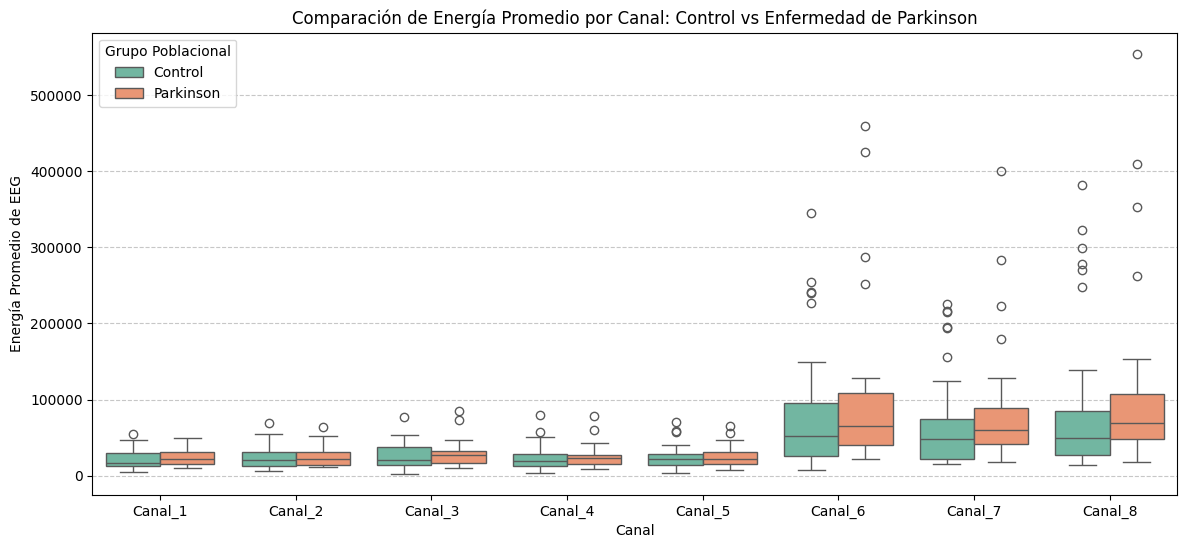

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. OBTENER LA LISTA DE CANALES
canales = df_control.columns
resultados_estadisticos = []

print("--- ANÁLISIS ESTADÍSTICO POR CANAL ---")

# 2. BUCLE PARA EVALUAR CADA CANAL INDIVIDUALMENTE
for canal in canales:
    # Extraer los datos del canal para cada grupo
    data_c = df_control[canal].dropna()
    data_p = df_parkinson[canal].dropna()
    
    # A) Prueba de Normalidad (Shapiro-Wilk)
    # H0: Los datos son normales. Rechazamos si p < 0.05
    _, p_sw_c = stats.shapiro(data_c)
    _, p_sw_p = stats.shapiro(data_p)
    es_normal = (p_sw_c > 0.05) and (p_sw_p > 0.05)
    
    # B) Prueba de Homocedasticidad (Levene)
    # H0: Las varianzas son iguales. Rechazamos si p < 0.05
    _, p_lev = stats.levene(data_c, data_p)
    es_homocedastico = p_lev > 0.05
    
    # C) Justificación y Selección de la Prueba
    if es_normal and es_homocedastico:
        prueba_usada = "T-Student (Paramétrica)"
        _, p_test = stats.ttest_ind(data_c, data_p)
    else:
        prueba_usada = "U Mann-Whitney (No Paramétrica)"
        _, p_test = stats.mannwhitneyu(data_c, data_p)
        
    # D) Evaluación de Diferencias (Alfa = 0.05)
    # H0: No hay diferencia entre grupos. Rechazamos si p < 0.05
    diferencia = "SÍ" if p_test < 0.05 else "NO"
    
    # Guardar resultados
    resultados_estadisticos.append({
        'Canal': canal,
        'Normalidad (Ambos)': es_normal,
        'Varianzas Iguales': es_homocedastico,
        'Prueba Seleccionada': prueba_usada,
        'Valor p (Prueba)': round(p_test, 4),
        'Diferencia Significativa': diferencia
    })

# 3. MOSTRAR TABLA DE RESULTADOS
df_resultados = pd.DataFrame(resultados_estadisticos)
display(df_resultados)

# ==========================================
# 4. REPRESENTACIÓN GRÁFICA (BOXPLOT)
# ==========================================
# Preparamos los datos juntándolos en un solo formato para Seaborn
df_c_plot = df_control.copy()
df_c_plot['Grupo'] = 'Control'

df_p_plot = df_parkinson.copy()
df_p_plot['Grupo'] = 'Parkinson'

# Concatenar y reorganizar  para poder graficar todos los canales a la vez
df_total = pd.concat([df_c_plot, df_p_plot])
df_melted = df_total.melt(id_vars='Grupo', value_vars=canales, var_name='Canal', value_name='Energía')

# Crear la gráfica
plt.figure(figsize=(14, 6))
sns.boxplot(x='Canal', y='Energía', hue='Grupo', data=df_melted, palette='Set2')
plt.title('Comparación de Energía Promedio por Canal: Control vs Enfermedad de Parkinson')
plt.ylabel('Energía Promedio de EEG')
plt.xlabel('Canal')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Grupo Poblacional')
plt.show()

#### Análisis de resultados de las pruebas estadísticas

Al evaluar la energía total promedio del EEG crudo en los 8 canales, las pruebas de Mann-Whitney arrojaron valores $p > 0.05$, indicando la ausencia de diferencias estadísticamente significativas entre el grupo control y los pacientes con Parkinson. Este resultado es respaldado visualmente por el diagrama de cajas, el cual revela un solapamiento poblacional casi total y una varianza inter-sujeto extrema (múltiples valores atípicos) en ambos grupos. 

La falta de significancia y la alta dispersión se atribuyen metodológicamente a la ausencia de preprocesamiento en las señales. Matemáticamente, el cálculo de la energía discreta ($E = \sum |x[n]|^2$) amplifica cuadráticamente cualquier anomalía en la amplitud. Al no aplicar un filtro *Notch* (para ruido eléctrico de la red) ni un filtro Pasabanda, el cálculo integró artefactos de alto voltaje fisiológico (parpadeos, EOG, EMG) y ruido técnico (fluctuaciones de impedancia), enmascarando la actividad cortical real. 

Adicionalmente, el análisis de espectro completo resulta insuficiente para esta patología. La literatura clínica establece que los marcadores electroencefalográficos del Parkinson no se reflejan en la energía global cruda, sino en la distribución de la densidad espectral de potencia, específicamente a través de alteraciones en las bandas de frecuencia Beta y Gamma. En conclusión, para que la energía adquiera valor como característica discriminante, es indispensable implementar etapas previas de filtrado y extracción por ritmos cerebrales específicos.

#### Conclusiones


- Se determina que la energía total de la señal de EEG cruda, por sí sola, carece de la robustez y especificidad necesarias para actuar como una característica discriminante entre ambos grupos. Para estudios futuros, es indispensable implementar una etapa de filtrado (filtro Notch para la red eléctrica y filtro Pasabanda de 1 a 45 Hz) y realizar una extracción de características basada en la densidad espectral de potencia (energía relativa por ritmos cerebrales) para mitigar la varianza inter-sujeto y obtener resultados con validez clínica.

#### **Referencias**

1. Urigüen, J. A., & Garcia-Zapirain, B. (2015). EEG artifact removal—state-of-the-art and guidelines. Journal of Neural Engineering, 12(3), 031001. Tomado de : https://www.researchgate.net/publication/274397371_EEG_artifact_removal-state-of-the-art_and_guidelines

2. Al-Fahoum, A. S., & Al-Fraihat, A. A. (2014). Methods of EEG signal features extraction using linear analysis in frequency and Time-Frequency domains. ISRN Neuroscience, 2014, 1–7. https://doi.org/10.1155/2014/730218. Tomado de : https://pmc.ncbi.nlm.nih.gov/articles/PMC4045570/

3. Chaturvedi, M., Hatz, F., Gschwandtner, U., Bogaarts, J. G., Meyer, A., Fuhr, P., & Roth, V. (2017). Quantitative EEG (QEEG) Measures Differentiate Parkinson’s Disease (PD) Patients from Healthy Controls (HC). Frontiers in Aging Neuroscience, 9, 3. https://doi.org/10.3389/fnagi.2017.00003